# Input Classifier — S1 Strategy (final)

Binary classifier on `(system_prompt, prompt)` predicting whether the query is off-topic. Acts as the guardrail directly: predicted off-topic → block; predicted on-topic → allow.

**Setup**
- Model: `roberta-base`
- Hardware: Google Colab Pro, H100
- Train: 10k subset from `gabrielchua/off-topic`
- Test: 500-row held-out eval set

**Outputs (saved to disk for cross-strategy comparison)**
- `s1_input_metrics.json` — matches the S4 LoRA schema for direct comparison
- `s1_input_predictions.csv` — per-sample predictions for ensemble/diagnostic analysis
- `s1_input_history.json` — per-epoch training history
- `best_model/` — saved checkpoint


In [9]:
!pip install -q -U transformers datasets accelerate scikit-learn seaborn matplotlib

In [10]:
import os, random, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    matthews_corrcoef,
)

SEED = 42
set_seed(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.10.0+cu128
GPU: NVIDIA A100-SXM4-80GB | 85.1 GB


In [11]:
CONFIG = {
    "model_name": "roberta-base",
    "max_length": 512,
    "batch_size": 32,
    "eval_batch_size": 64,
    "num_epochs": 10,                  # ceiling — early stopping cuts off sooner
    "early_stopping_patience": 2,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "cosine",
    "val_split": 0.1,
    "output_dir": "./s1_input_classifier_output",
    "train_csv_path": "sampled_5k.csv",
    "test_csv_path":  "eval_500.csv",

    # Strategy metadata for the JSON output
    "strategy_name": "S1_input_classifier",
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
LABELS = ("on_topic", "off_topic")  # 0, 1


## 1. Load data + EDA

In [12]:
train_df = pd.read_csv(CONFIG["train_csv_path"])
test_df  = pd.read_csv(CONFIG["test_csv_path"])

for df in (train_df, test_df):
    for col in ("__index_level_0__", "prompt_word_count"):
        if col in df.columns:
            df.drop(columns=col, inplace=True)
    df.dropna(subset=["off_topic", "system_prompt", "prompt"], inplace=True)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nTrain class balance: {train_df['off_topic'].value_counts().to_dict()}")
print(f"Test  class balance: {test_df['off_topic'].value_counts().to_dict()}")


Train: 5000 | Test: 500
Columns: ['system_prompt', 'prompt', 'off_topic']

Train class balance: {0: 2500, 1: 2500}
Test  class balance: {0: 250, 1: 250}


In [13]:
# Stratified 90/10 train/val split
train_split_df, val_split_df = train_test_split(
    train_df, test_size=CONFIG["val_split"],
    stratify=train_df["off_topic"], random_state=SEED,
)
print(f"Train: {len(train_split_df)} | Val: {len(val_split_df)} | Test: {len(test_df)}")


Train: 4500 | Val: 500 | Test: 500


## 2. Tokenize

In [14]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def tokenize_pair(batch):
    return tokenizer(
        batch["system_prompt"], batch["prompt"],
        truncation="longest_first", max_length=CONFIG["max_length"],
        padding=False,
    )

def df_to_tokenized(df):
    ds = Dataset.from_pandas(
        df[["system_prompt", "prompt", "off_topic"]].rename(columns={"off_topic": "labels"}),
        preserve_index=False,
    )
    return ds.map(tokenize_pair, batched=True, remove_columns=["system_prompt", "prompt"])

train_ds = df_to_tokenized(train_split_df)
val_ds   = df_to_tokenized(val_split_df)
test_ds  = df_to_tokenized(test_df)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Token length sanity check
sample_lens = [len(tokenizer(r["system_prompt"], r["prompt"])["input_ids"])
               for _, r in train_split_df.sample(min(500, len(train_split_df)), random_state=SEED).iterrows()]
sample_lens = np.array(sample_lens)
print(f"Pair token length — p50: {np.median(sample_lens):.0f}, p95: {np.percentile(sample_lens, 95):.0f}, "
      f"max: {sample_lens.max()}, % over {CONFIG['max_length']}: {(sample_lens > CONFIG['max_length']).mean()*100:.1f}%")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train: 4500 | Val: 500 | Test: 500
Pair token length — p50: 136, p95: 236, max: 394, % over 512: 0.0%


## 3. Model

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"], num_labels=2,
    id2label={0: "on_topic", 1: "off_topic"},
    label2id={"on_topic": 0, "off_topic": 1},
)
print(f"Model: {CONFIG['model_name']}  |  {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params")


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base  |  124.6M params


## 4. Metrics + per-epoch confusion matrix

In [16]:
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  accuracy={((tp+tn)/cm.sum()):.4f}  "
          f"recall_offtopic={tp/(tp+fn) if (tp+fn) else 0:.4f}  "
          f"FPR={fp/(fp+tn) if (fp+tn) else 0:.4f}")
    return cm


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", pos_label=1, zero_division=0)
    _, _, f1_macro, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy": acc,
        "precision_offtopic": p, "recall_offtopic": r,
        "f1_offtopic": f1, "f1_macro": f1_macro,
        "fpr": fp / (fp + tn) if (fp + tn) else 0.0,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


class EpochCMCallback(TrainerCallback):
    def __init__(self):
        self.history = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        epoch = state.epoch if state.epoch is not None else 0
        tn, fp, fn, tp = metrics.get("eval_tn"), metrics.get("eval_fp"), metrics.get("eval_fn"), metrics.get("eval_tp")
        if None in (tn, fp, fn, tp): return
        cm = np.array([[tn, fp], [fn, tp]])
        self.history.append({"epoch": float(epoch), "cm": cm.tolist(),
                             "metrics": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                                         for k, v in metrics.items()}})
        fig, ax = plt.subplots(figsize=(5.0, 4.0))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"Validation CM — epoch {epoch:.0f}")
        plt.tight_layout(); plt.show()
        print(f"  epoch {epoch:.0f}  |  acc={metrics.get('eval_accuracy', 0):.4f}  "
              f"f1={metrics.get('eval_f1_offtopic', 0):.4f}  "
              f"recall={metrics.get('eval_recall_offtopic', 0):.4f}  "
              f"fpr={metrics.get('eval_fpr', 0):.4f}")


## 5. Train

In [17]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["eval_batch_size"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],
    lr_scheduler_type=CONFIG["lr_scheduler_type"],
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_offtopic",
    greater_is_better=True,
    save_total_limit=2,
    bf16=use_bf16, fp16=False,
    report_to="none", seed=SEED,
    dataloader_pin_memory=True,
    remove_unused_columns=True,
)

cm_cb = EpochCMCallback()

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[cm_cb, EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])],
)
print(f"BF16: {use_bf16}  |  Total max steps: {len(train_ds) // CONFIG['batch_size'] * CONFIG['num_epochs']}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


BF16: True  |  Total max steps: 1400


Epoch,Training Loss,Validation Loss,Accuracy,Precision Offtopic,Recall Offtopic,F1 Offtopic,F1 Macro,Fpr,Tn,Fp,Fn,Tp
1,0.650020,0.147498,0.958000,0.979079,0.936000,0.957055,0.957980,0.020000,245,5,16,234
2,0.136589,0.142414,0.968000,0.975610,0.960000,0.967742,0.967998,0.024000,244,6,10,240
3,0.050569,0.105291,0.974000,0.968379,0.980000,0.974155,0.973999,0.032000,242,8,5,245
4,0.032045,0.109732,0.980000,0.987805,0.972000,0.979839,0.979999,0.012000,247,3,7,243
5,0.010154,0.138418,0.978000,0.987755,0.968000,0.977778,0.977998,0.012000,247,3,8,242
6,0.012218,0.124258,0.982000,0.976285,0.988000,0.982107,0.981999,0.024000,244,6,3,247
7,0.000145,0.167375,0.978000,0.987755,0.968000,0.977778,0.977998,0.012000,247,3,8,242
8,0.004267,0.139123,0.978000,0.979920,0.976000,0.977956,0.978000,0.020000,245,5,6,244


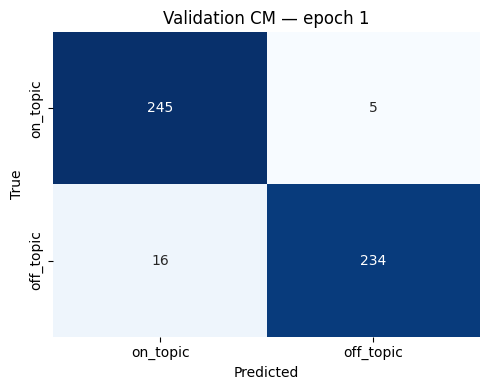

  epoch 1  |  acc=0.9580  f1=0.9571  recall=0.9360  fpr=0.0200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

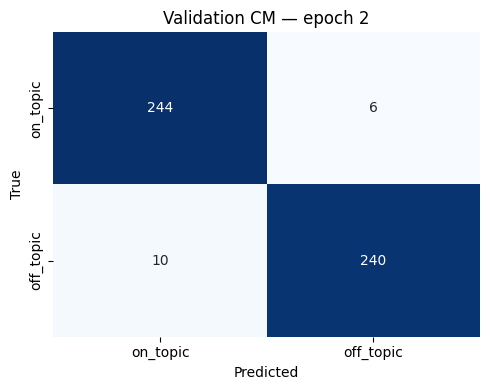

  epoch 2  |  acc=0.9680  f1=0.9677  recall=0.9600  fpr=0.0240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

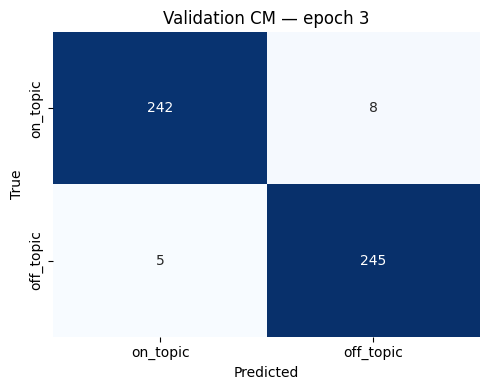

  epoch 3  |  acc=0.9740  f1=0.9742  recall=0.9800  fpr=0.0320


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

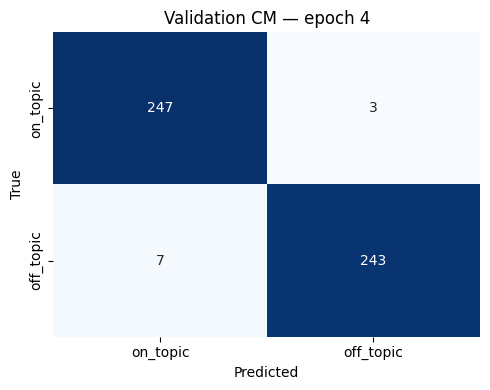

  epoch 4  |  acc=0.9800  f1=0.9798  recall=0.9720  fpr=0.0120


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

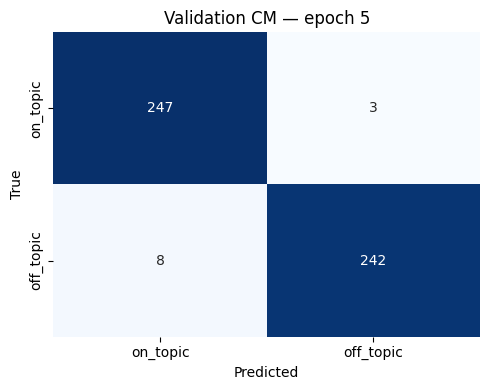

  epoch 5  |  acc=0.9780  f1=0.9778  recall=0.9680  fpr=0.0120


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

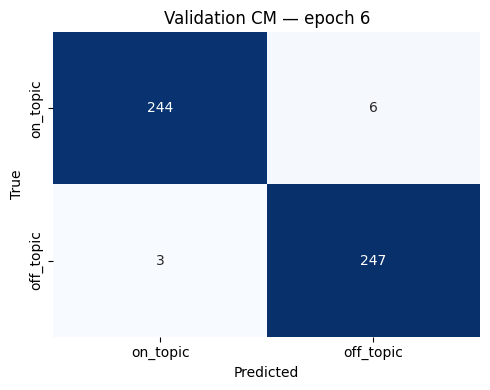

  epoch 6  |  acc=0.9820  f1=0.9821  recall=0.9880  fpr=0.0240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

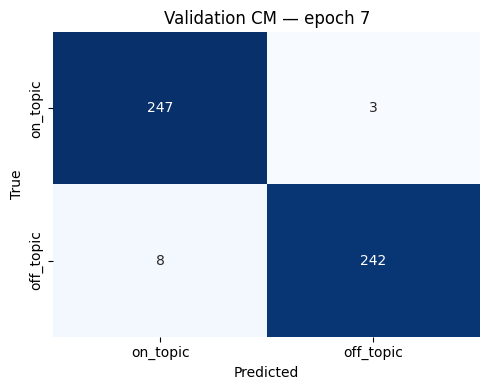

  epoch 7  |  acc=0.9780  f1=0.9778  recall=0.9680  fpr=0.0120


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

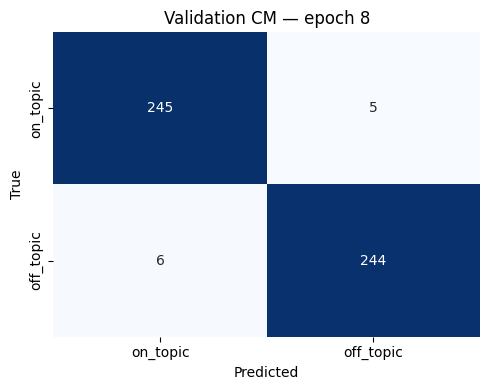

  epoch 8  |  acc=0.9780  f1=0.9780  recall=0.9760  fpr=0.0200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Train runtime: 103.5s  |  final loss: 0.1077


In [18]:
train_result = trainer.train()
print(f"\nTrain runtime: {train_result.metrics.get('train_runtime', 0):.1f}s  |  "
      f"final loss: {train_result.metrics.get('train_loss', 0):.4f}")


## 6. Final evaluation

VALIDATION SET


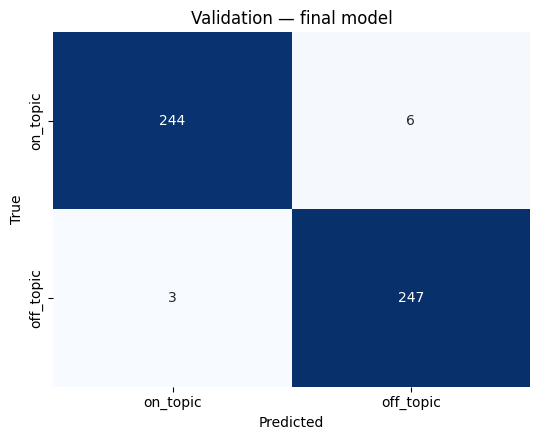

  TN=244  FP=6  FN=3  TP=247
  accuracy=0.9820  recall_offtopic=0.9880  FPR=0.0240
              precision    recall  f1-score   support

    on_topic     0.9879    0.9760    0.9819       250
   off_topic     0.9763    0.9880    0.9821       250

    accuracy                         0.9820       500
   macro avg     0.9821    0.9820    0.9820       500
weighted avg     0.9821    0.9820    0.9820       500



In [19]:
print("=" * 60); print("VALIDATION SET"); print("=" * 60)
val_pred = trainer.predict(val_ds)
val_preds = np.argmax(val_pred.predictions, axis=1)
val_labels = val_pred.label_ids
plot_cm(val_labels, val_preds, title="Validation — final model")
print(classification_report(val_labels, val_preds, target_names=LABELS, digits=4))


TEST SET (held-out eval — primary benchmark)


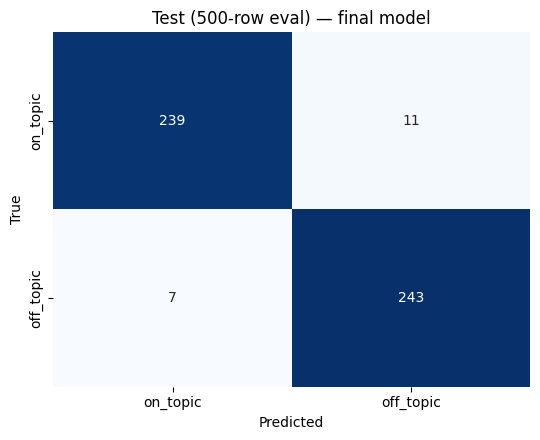

  TN=239  FP=11  FN=7  TP=243
  accuracy=0.9640  recall_offtopic=0.9720  FPR=0.0440
              precision    recall  f1-score   support

    on_topic     0.9715    0.9560    0.9637       250
   off_topic     0.9567    0.9720    0.9643       250

    accuracy                         0.9640       500
   macro avg     0.9641    0.9640    0.9640       500
weighted avg     0.9641    0.9640    0.9640       500



In [20]:
print("=" * 60); print("TEST SET (held-out eval — primary benchmark)"); print("=" * 60)
test_pred = trainer.predict(test_ds)
test_logits = test_pred.predictions
test_preds = np.argmax(test_logits, axis=1)
test_labels = test_pred.label_ids
plot_cm(test_labels, test_preds, title="Test (500-row eval) — final model")
print(classification_report(test_labels, test_preds, target_names=LABELS, digits=4))

# Probability of off-topic for downstream curves & threshold sweep
test_probs = torch.softmax(torch.from_numpy(test_logits), dim=-1).numpy()
prob_offtopic = test_probs[:, 1]


In [21]:
# Per-epoch summary
print(f"{'epoch':>6} | {'acc':>7} | {'f1':>7} | {'recall':>7} | {'fpr':>7}")
print("-" * 50)
for h in cm_cb.history:
    m = h["metrics"]
    print(f"{h['epoch']:>6.0f} | {m['eval_accuracy']:>7.4f} | "
          f"{m['eval_f1_offtopic']:>7.4f} | {m['eval_recall_offtopic']:>7.4f} | "
          f"{m['eval_fpr']:>7.4f}")


 epoch |     acc |      f1 |  recall |     fpr
--------------------------------------------------
     1 |  0.9580 |  0.9571 |  0.9360 |  0.0200
     2 |  0.9680 |  0.9677 |  0.9600 |  0.0240
     3 |  0.9740 |  0.9742 |  0.9800 |  0.0320
     4 |  0.9800 |  0.9798 |  0.9720 |  0.0120
     5 |  0.9780 |  0.9778 |  0.9680 |  0.0120
     6 |  0.9820 |  0.9821 |  0.9880 |  0.0240
     7 |  0.9780 |  0.9778 |  0.9680 |  0.0120
     8 |  0.9780 |  0.9780 |  0.9760 |  0.0200


## 7. ROC, PR, threshold sweep

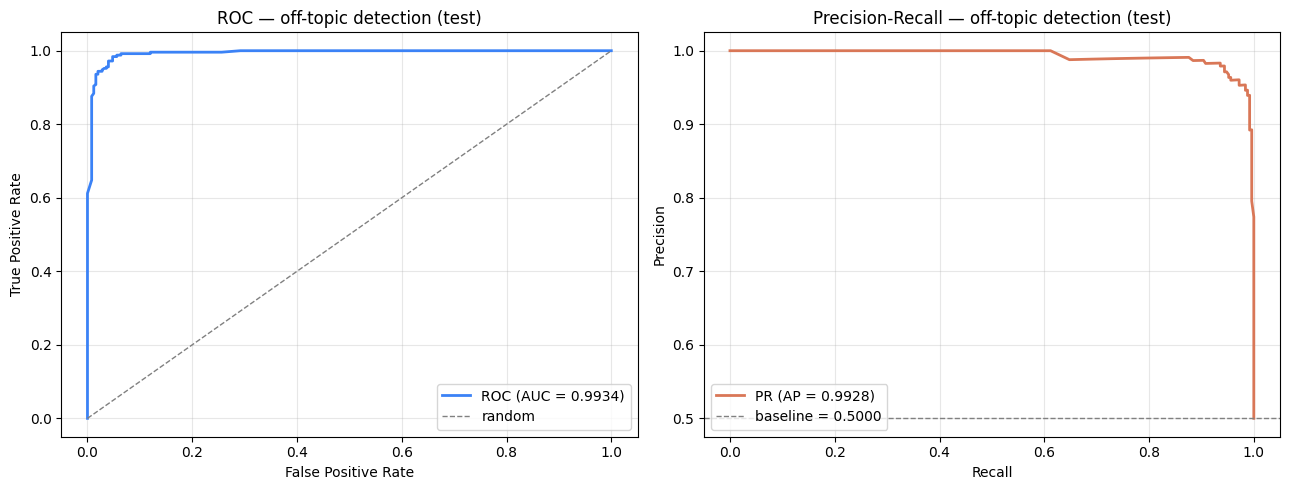

ROC-AUC: 0.9934  |  Average Precision: 0.9928  (baseline 0.5000)


In [22]:
fpr, tpr, _ = roc_curve(test_labels, prob_offtopic)
roc_auc = auc(fpr, tpr)
prec_curve, rec_curve, _ = precision_recall_curve(test_labels, prob_offtopic)
ap = average_precision_score(test_labels, prob_offtopic)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, lw=2, color="#3b82f6", label=f"ROC (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], lw=1, ls="--", color="grey", label="random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — off-topic detection (test)"); axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].plot(rec_curve, prec_curve, lw=2, color="#d97757", label=f"PR (AP = {ap:.4f})")
baseline_ap = test_labels.mean()
axes[1].axhline(baseline_ap, ls="--", color="grey", lw=1, label=f"baseline = {baseline_ap:.4f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — off-topic detection (test)"); axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"ROC-AUC: {roc_auc:.4f}  |  Average Precision: {ap:.4f}  (baseline {baseline_ap:.4f})")


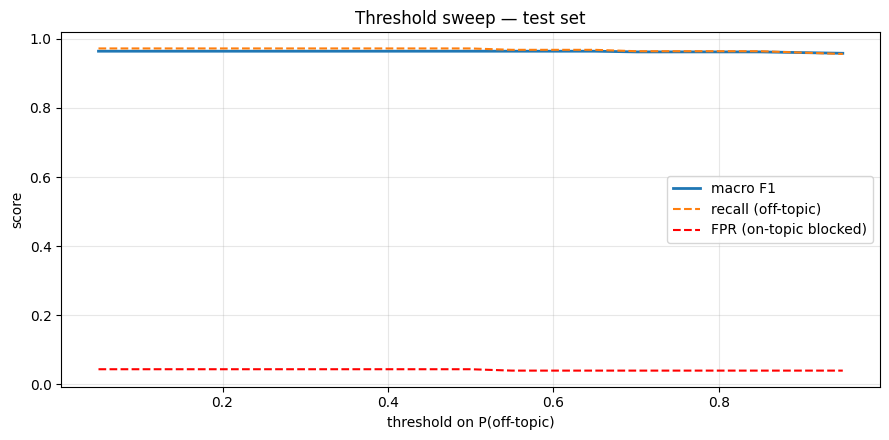

Best macro F1: 0.9640 at threshold 0.55  (recall_offtopic=0.9680, fpr=0.0400)


In [23]:
# Threshold sweep — track macro-F1 to pick the right operating point
thresholds = np.linspace(0.05, 0.95, 19)
sweep = []
for t in thresholds:
    p = (prob_offtopic >= t).astype(int)
    cm = confusion_matrix(test_labels, p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    rec_off = tp / (tp + fn) if (tp + fn) else 0.0
    prec_off = tp / (tp + fp) if (tp + fp) else 0.0
    f1_off = 2*prec_off*rec_off/(prec_off+rec_off) if (prec_off+rec_off) else 0.0
    rec_on = tn / (tn + fp) if (tn + fp) else 0.0
    prec_on = tn / (tn + fn) if (tn + fn) else 0.0
    f1_on = 2*prec_on*rec_on/(prec_on+rec_on) if (prec_on+rec_on) else 0.0
    sweep.append({"thr": t, "f1_offtopic": f1_off, "f1_ontopic": f1_on,
                  "f1_macro": (f1_off + f1_on) / 2,
                  "recall_offtopic": rec_off, "fpr": fp/(fp+tn) if (fp+tn) else 0.0})
sweep_df = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sweep_df["thr"], sweep_df["f1_macro"], label="macro F1", lw=2)
ax.plot(sweep_df["thr"], sweep_df["recall_offtopic"], label="recall (off-topic)", lw=1.5, ls="--")
ax.plot(sweep_df["thr"], sweep_df["fpr"], label="FPR (on-topic blocked)", lw=1.5, ls="--", color="red")
ax.set_xlabel("threshold on P(off-topic)"); ax.set_ylabel("score")
ax.set_title("Threshold sweep — test set"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

best = sweep_df.loc[sweep_df["f1_macro"].idxmax()]
print(f"Best macro F1: {best['f1_macro']:.4f} at threshold {best['thr']:.2f}  "
      f"(recall_offtopic={best['recall_offtopic']:.4f}, fpr={best['fpr']:.4f})")


## 8. Metrics in cross-strategy JSON format

Matches the S4 LoRA schema for direct comparison. Schema:
- `compliance_col`: name of the per-sample compliance column we'd save
- positive class = `off_topic` (i.e., "should be blocked")
- `compliance` = `1 - predicted_off_topic` (let through = complied, blocked = refused)
- `compliance_rate_offtopic` = fraction of true off-topic queries that got let through (guardrail failure rate)
- `compliance_rate_ontopic` = fraction of true on-topic queries correctly let through


In [24]:
import json, os

y_true = np.asarray(test_labels).astype(int)
y_pred = np.asarray(test_preds).astype(int)

tp = int(((y_true == 1) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())

n, n_off, n_on = len(y_true), int((y_true == 1).sum()), int((y_true == 0).sum())
prec = tp / (tp + fp) if (tp + fp) else 0.0
rec  = tp / (tp + fn) if (tp + fn) else 0.0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

metrics = {
    "compliance_col": "input_classifier_pred",
    "total_samples": n,
    "compliance_rate_offtopic": round(fn / n_off, 4),
    "compliance_rate_ontopic":  round(tn / n_on,  4),
    "guardrail_accuracy":       round((tp + tn) / n, 4),
    "guardrail_f1":             round(f1, 4),
    "false_positive_rate":      round(fp / n_on, 4),
    "true_positives":  tp, "false_negatives": fn,
    "true_negatives":  tn, "false_positives": fp,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
with open(os.path.join(CONFIG["output_dir"], "s1_input_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

{
  "compliance_col": "input_classifier_pred",
  "total_samples": 500,
  "compliance_rate_offtopic": 0.028,
  "compliance_rate_ontopic": 0.956,
  "guardrail_accuracy": 0.964,
  "guardrail_f1": 0.9643,
  "false_positive_rate": 0.044,
  "true_positives": 243,
  "false_negatives": 7,
  "true_negatives": 239,
  "false_positives": 11
}


In [25]:
# Save artifacts for the team's cross-strategy comparison
metrics_path = os.path.join(CONFIG["output_dir"], "s1_input_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved metrics → {metrics_path}")

# Per-sample predictions (for ensemble analysis or error inspection)
pred_df = test_df.copy().reset_index(drop=True)
pred_df["predicted_off_topic"] = test_preds.astype(int)
pred_df["prob_offtopic"] = prob_offtopic.round(4)
# Convention: compliance = 1 if let through, 0 if blocked
pred_df["input_classifier_pred"] = (1 - test_preds).astype(int)
pred_path = os.path.join(CONFIG["output_dir"], "s1_input_predictions.csv")
pred_df.to_csv(pred_path, index=False)
print(f"Saved predictions → {pred_path}  ({len(pred_df)} rows)")

# Per-epoch training history
hist_path = os.path.join(CONFIG["output_dir"], "s1_input_history.json")
with open(hist_path, "w") as f:
    json.dump(cm_cb.history, f, indent=2)
print(f"Saved history → {hist_path}")


Saved metrics → ./s1_input_classifier_output/s1_input_metrics.json
Saved predictions → ./s1_input_classifier_output/s1_input_predictions.csv  (500 rows)
Saved history → ./s1_input_classifier_output/s1_input_history.json


## 9. Save model

In [26]:
save_path = os.path.join(CONFIG["output_dir"], "best_model")
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Saved model → {save_path}")

# Tip: copy everything to Drive so it persists across Colab sessions:
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r {CONFIG["output_dir"]} /content/drive/MyDrive/s1_input_classifier_artifacts


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model → ./s1_input_classifier_output/best_model


In [27]:
@torch.no_grad()
def classify(system_prompt: str, user_prompt: str, threshold: float = 0.5):
    model.eval()
    enc = tokenizer(system_prompt, user_prompt,
                    truncation="longest_first", max_length=CONFIG["max_length"],
                    padding=True, return_tensors="pt").to(model.device)
    logits = model(**enc).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred = int(probs[1] >= threshold)
    return {
        "predicted_off_topic": pred,
        "would_block": bool(pred),
        "P(off_topic)": float(probs[1]),
        "P(on_topic)": float(probs[0]),
    }

sys_p = (
    "### TASK-BOT ###\nOBJECTIVE: Provide project management advice for remote teams.\n"
    "Avoid unrelated personal opinions."
)
print("On-topic:", classify(sys_p, "Tips for evaluating employee performance remotely?"))
print("Off-topic:", classify(sys_p, "Write me a Python script that scrapes Amazon listings."))
print("Off-topic:", classify(sys_p, "What's a good chocolate chip cookie recipe?"))


On-topic: {'predicted_off_topic': 0, 'would_block': False, 'P(off_topic)': 6.014151585986838e-05, 'P(on_topic)': 0.9999397993087769}
Off-topic: {'predicted_off_topic': 1, 'would_block': True, 'P(off_topic)': 0.9999469518661499, 'P(on_topic)': 5.3075080359121785e-05}
Off-topic: {'predicted_off_topic': 1, 'would_block': True, 'P(off_topic)': 0.9999452829360962, 'P(on_topic)': 5.475977013702504e-05}
